In [ ]:
import numpy as np 
import pandas as pd 

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/multiple-linear-regression-dataset/multiple_linear_regression_dataset.csv


In [2]:
df = pd.read_csv('/kaggle/input/multiple-linear-regression-dataset/multiple_linear_regression_dataset.csv')
df.head()

,age,experience,income
0,25,1,30450
1,30,3,35670
2,47,2,31580
3,32,5,40130
4,43,10,47830


/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


<Axes: xlabel='income', ylabel='Count'>

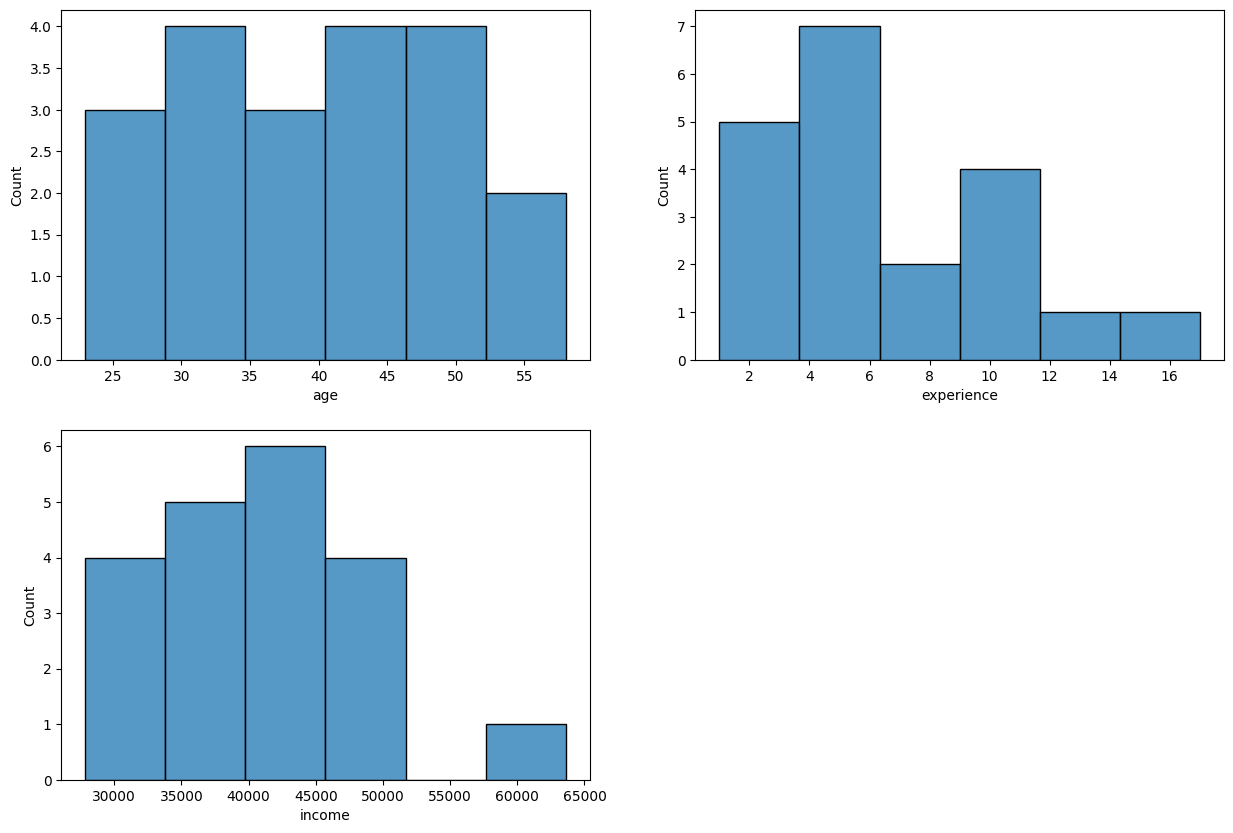

In [3]:
import seaborn as sns
import matplotlib.pyplot as plt
plt.figure(figsize = (15,10))
plt.subplot(2,2,1)
sns.histplot(df['age'])

plt.subplot(2,2,2)
sns.histplot(df['experience'])

plt.subplot(2,2,3)
sns.histplot(df['income'])

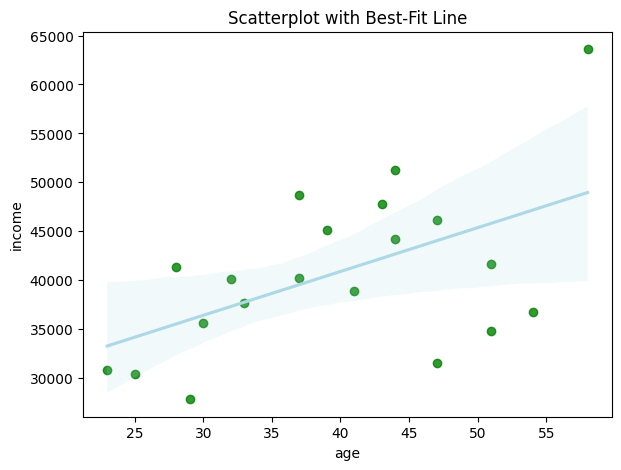

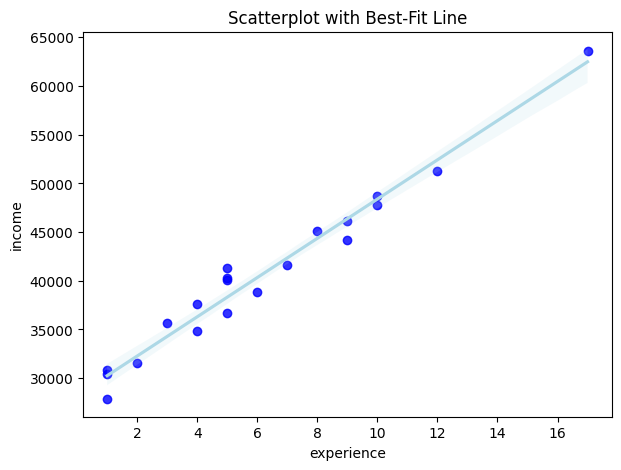

In [4]:
plt.figure(figsize = (15,5))

plt.subplot(1,2,1)
sns.regplot(data=df, x="age", y="income",color="green", line_kws={"color": "lightblue"})
plt.title("Scatterplot with Best-Fit Line")
plt.show()

plt.figure(figsize = (15,5))
plt.subplot(1,2,2)
sns.regplot(data=df, x="experience", y="income",color="blue", line_kws={"color": "lightblue"})
plt.title("Scatterplot with Best-Fit Line")
plt.show()

<Axes: >

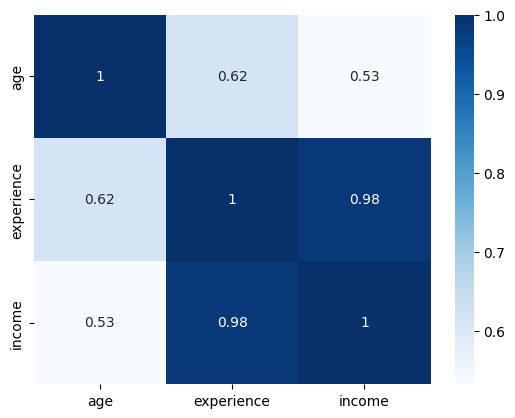

In [5]:
cor = df.corr()
sns.heatmap(cor, annot = True, cmap = 'Blues')

In [6]:
x = df.drop(columns = 'income').values
y = df['income'].values

In [ ]:
ones = np.ones((x.shape[0],1))
x = np.hstack([ones,x])
print(x)

[[ 1. 25.  1.]
 [ 1. 30.  3.]
 [ 1. 47.  2.]
 [ 1. 32.  5.]
 [ 1. 43. 10.]
 [ 1. 51.  7.]
 [ 1. 28.  5.]
 [ 1. 33.  4.]
 [ 1. 37.  5.]
 [ 1. 39.  8.]
 [ 1. 29.  1.]
 [ 1. 47.  9.]
 [ 1. 54.  5.]
 [ 1. 51.  4.]
 [ 1. 44. 12.]
 [ 1. 41.  6.]
 [ 1. 58. 17.]
 [ 1. 23.  1.]
 [ 1. 44.  9.]
 [ 1. 37. 10.]]


In [8]:
y = y.reshape(-1,1)
print(y)

[[30450]
 [35670]
 [31580]
 [40130]
 [47830]
 [41630]
 [41340]
 [37650]
 [40250]
 [45150]
 [27840]
 [46110]
 [36720]
 [34800]
 [51300]
 [38900]
 [63600]
 [30870]
 [44190]
 [48700]]


In [9]:
XT = x.T
XTX = XT.dot(x)
XTX_inv = np.linalg.inv(XTX)
XTy = XT.dot(y)
B = XTX_inv.dot(XTy)
print(B)

[[31261.6898541 ]
 [  -99.19535546]
 [ 2162.40419192]]


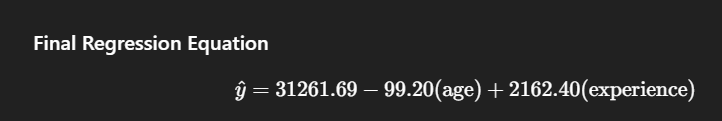


In [ ]:
ypred = x.dot(B)
y_mean = np.mean(y)
ss_res = np.sum((y - ypred)**2)
ss_tot = np.sum((y - y_mean)**2)
R2 = 1 - (ss_res/ss_tot)
print(R2)

0.9773361310180797


In [ ]:
compare = pd.DataFrame({
    'Actual':df['income'],
    'Predicted': ypred.flatten()
})
print(compare)

    Actual     Predicted
0    30450  30944.210159
1    35670  34773.041766
2    31580  30924.316531
3    40130  38899.459439
4    47830  48620.331489
5    41630  41339.556069
6    41340  39296.240861
7    37650  36637.859892
8    40250  38403.482662
9    45150  44692.304527
10   27840  30547.428738
11   46110  46061.145875
12   36720  36717.161619
13   34800  34852.343493
14   51300  52845.944517
15   38900  40169.105432
16   63600  62269.230500
17   30870  31142.600870
18   44190  46358.731941
19   48700  49215.503621
